<a href="https://colab.research.google.com/github/Shamiul-693/CICadversarial/blob/main/Robust_Federated_Learning_for_Adversarial_Attack_Detection_in_Resource_Constrained_IoT_Ecosystems_A_Privacy_Preserving_Framework_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
# tensorflow
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Flatten, Concatenate, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Install kaggle library
!pip install kaggle

# Upload your kaggle.json API key file
from google.colab import files
files.upload()  # Upload kaggle.json here when prompted

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shamiulislam693","key":"7457fbbeb1f26124e027793803020888"}'}

In [4]:
import os

# Move kaggle.json to the correct directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key configured successfully!")

Kaggle API key configured successfully!


In [5]:
# Download the dataset from Kaggle
!kaggle datasets download -d mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot

# Unzip the downloaded file
!unzip edgeiiotset-cyber-security-dataset-of-iot-iiot.zip -d /content/Edge-IIoTset

print("Dataset downloaded and extracted successfully!")

Dataset URL: https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot
License(s): CC-BY-NC-SA-4.0
100% 1.63G/1.63G [00:15<00:00, 115MB/s]

Archive:  edgeiiotset-cyber-security-dataset-of-iot-iiot.zip
  inflating: /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/Backdoor_attack.csv  
  inflating: /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/Backdoor_attack.pcap  
  inflating: /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/DDoS HTTP Flood Attacks.pcap  
  inflating: /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/DDoS ICMP Flood Attacks.pcap  
  inflating: /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/DDoS TCP SYN Flood Attacks.pcap  
  inflating: /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/DDoS UDP Flood Attacks.pcap  
  inflating: /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/DDoS_HTTP_Flood_attack.csv  
  inflating: /content/Edge-IIoTset/Edge-IIoTset dataset/Attack

In [6]:
# Check the folder structure
import os

dataset_path = "/content/Edge-IIoTset"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

Edge-IIoTset/
  Edge_IIoTset__DatasetFL.pdf
  Readme.txt
  Edge-IIoTset dataset/
    Attack traffic/
      Port Scanning attack.pcap
      Password_attack.csv
      DDoS_ICMP_Flood_attack.csv
      OS Fingerprinting attack.pcap
      DDoS HTTP Flood Attacks.pcap
      DDoS_UDP_Flood_attack.csv
      DDoS TCP SYN Flood Attacks.pcap
      XSS_attack.csv
      Uploading_attack.csv
      Uploading attack.pcap
      Password attacks.pcap
      DDoS ICMP Flood Attacks.pcap
      MITM (ARP spoofing + DNS) Attack.pcap
      Vulnerability scanner attack.pcap
      SQL_injection_attack.csv
      DDoS_HTTP_Flood_attack.csv
      Port_Scanning_attack.csv
      XSS attacks.pcap
      Ransomware_attack.csv
      SQL injection attack.pcap
      Vulnerability_scanner_attack.csv
      MITM_attack.csv
      DDoS UDP Flood Attacks.pcap
      Ransomware attack.pcap
      OS_Fingerprinting_attack.csv
      Backdoor_attack.pcap
      DDoS_TCP_SYN_Flood_attack.csv
      Backdoor_attack.csv
    Normal traffic

In [7]:
import pandas as pd
import glob

# Find all CSV files in the dataset
csv_files = glob.glob("/content/Edge-IIoTset/**/*.csv", recursive=True)

print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f" - {f}")

Found 26 CSV files:
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/Password_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/DDoS_ICMP_Flood_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/DDoS_UDP_Flood_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/XSS_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/Uploading_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/SQL_injection_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/DDoS_HTTP_Flood_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/Port_Scanning_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/Ransomware_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/Vulnerability_scanner_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack traffic/MITM_attack.csv
 - /content/Edge-IIoTset/Edge-IIoTset dataset/Attack

In [8]:
import pandas as pd

# Load the pre-filtered DNN version directly
df = pd.read_csv(
    "/content/Edge-IIoTset/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv",
    low_memory=False
)

print(f"Dataset loaded successfully! Shape: {df.shape}")

Dataset loaded successfully! Shape: (2219201, 63)


In [9]:
# Preview first few rows
print("=== First 5 Rows ===")
df.head()

=== First 5 Rows ===


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal


In [10]:
# Column names
print("=== Column Names ===")
print(df.columns.tolist())
print(f"\nTotal Columns: {df.shape[1]}")

=== Column Names ===
['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum', 'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused', 'http.file_data', 'http.content_length', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack', 'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack', 'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options', 'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream', 'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request', 'dns.retransmit_request_in', 'mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.msg', 'mqtt.msgtype', 'mqtt.proto_len', 'mqt

In [11]:
# Data types and non-null counts
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2219201 entries, 0 to 2219200
Data columns (total 63 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   frame.time                 object 
 1   ip.src_host                object 
 2   ip.dst_host                object 
 3   arp.dst.proto_ipv4         object 
 4   arp.opcode                 float64
 5   arp.hw.size                float64
 6   arp.src.proto_ipv4         object 
 7   icmp.checksum              float64
 8   icmp.seq_le                float64
 9   icmp.transmit_timestamp    float64
 10  icmp.unused                float64
 11  http.file_data             object 
 12  http.content_length        float64
 13  http.request.uri.query     object 
 14  http.request.method        object 
 15  http.referer               object 
 16  http.request.full_uri      object 
 17  http.request.version       object 
 18  http.response              float64
 19  http.tls_port        

Check Target Label (Attack Types)

In [12]:
print("=== Attack Type Distribution ===")
attack_counts = df['Attack_type'].value_counts()
print(attack_counts)

print(f"\nTotal Classes: {df['Attack_type'].nunique()}")

=== Attack Type Distribution ===
Attack_type
Normal                   1615643
DDoS_UDP                  121568
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
MITM                        1214
Fingerprinting              1001
Name: count, dtype: int64

Total Classes: 15


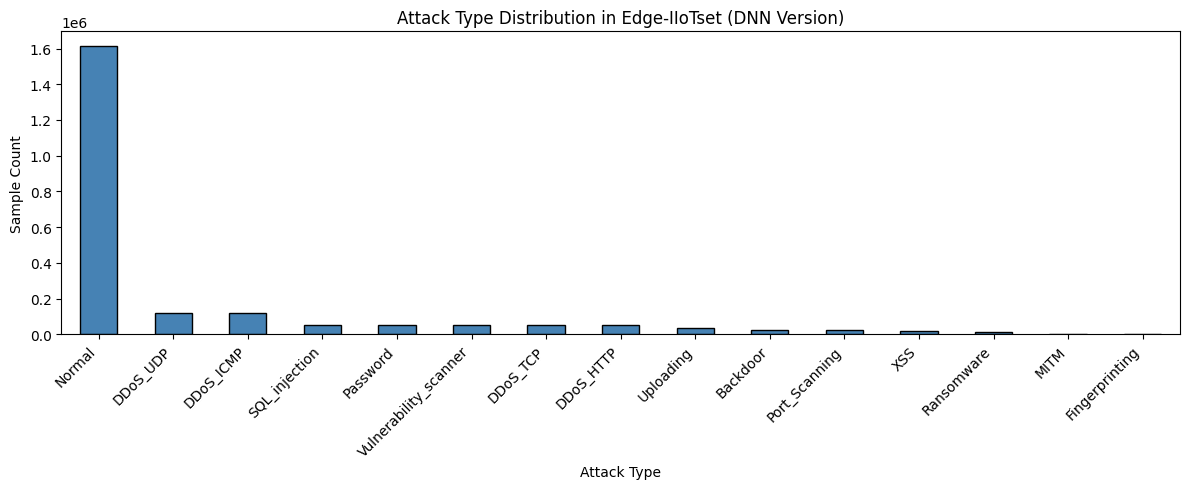

In [13]:
import matplotlib.pyplot as plt

# Visualize class distribution
plt.figure(figsize=(12, 5))
df['Attack_type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Attack Type Distribution in Edge-IIoTset (DNN Version)')
plt.xlabel('Attack Type')
plt.ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Check Missing Values**

In [14]:
print("=== Missing Values Per Column ===")
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print("No missing values found!")
else:
    print(missing_cols)
    print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

=== Missing Values Per Column ===
No missing values found!


# **Quick Statistics**

In [15]:
print("=== Basic Statistics ===")
df.describe()

=== Basic Statistics ===


,arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.content_length,http.response,http.tls_port,tcp.ack,...,mqtt.len,mqtt.msg_decoded_as,mqtt.msgtype,mqtt.proto_len,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label
count,2.219201e+06,2.219201e+06,2.219201e+06,2.219201e+06,2.219201e+06,2219201.0,2.219201e+06,2.219201e+06,2219201.0,2.219201e+06,...,2.219201e+06,2219201.0,2.219201e+06,2.219201e+06,2.219201e+06,2.219201e+06,2.219201e+06,2.219201e+06,2.219201e+06,2.219201e+06
mean,3.323268e-03,1.582732e-02,1.730285e+03,1.893064e+03,2.877556e+03,0.0,4.808231e+00,1.469132e-02,0.0,2.278400e+07,...,1.982731e+00,0.0,7.481643e-01,1.496665e-01,8.977934e-01,1.496665e-01,1.297764e-03,5.170780e-03,9.417804e-05,2.719709e-01
std,6.843237e-02,3.077555e-01,8.526581e+03,8.870474e+03,4.705188e+05,0.0,9.642259e+01,1.203142e-01,0.0,1.649033e+08,...,7.648797e+00,0.0,2.701086e+00,7.591219e-01,4.554231e+00,7.591219e-01,1.711483e-01,7.226807e-01,1.377313e-02,4.449751e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,...,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,1.000000e+00,...,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,6.000000e+00,...,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,5.900000e+01,...,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
max,2.000000e+00,6.000000e+00,6.553300e+04,6.553500e+04,7.728902e+07,0.0,8.365500e+04,1.000000e+00,0.0,3.949529e+09,...,3.900000e+01,0.0,1.400000e+01,4.000000e+00,2.400000e+01,4.000000e+00,2.700000e+01,1.510000e+02,6.000000e+00,1.000000e+00


# **2. Preprocessing & Cleaning**

Drop Unnecessary Columns

In [16]:
# Check for columns that are irrelevant for ML/DL
cols_to_drop = []

# Drop columns with only 1 unique value (no information)
for col in df.columns:
    if df[col].nunique() == 1:
        cols_to_drop.append(col)

print(f"Columns with single unique value (to drop): {cols_to_drop}")

# Also drop IP/MAC address columns if present (not useful for model)
ip_cols = [col for col in df.columns if any(x in col.lower()
           for x in ['ip', 'mac', 'addr', 'timestamp'])]
print(f"IP/MAC/Timestamp columns (to drop): {ip_cols}")

# Combine and drop
cols_to_drop = list(set(cols_to_drop + ip_cols))
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"\nDropped {len(cols_to_drop)} columns")
print(f"Remaining Shape: {df.shape}")

Columns with single unique value (to drop): ['icmp.unused', 'http.tls_port', 'dns.qry.type', 'mqtt.msg_decoded_as']
IP/MAC/Timestamp columns (to drop): ['ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.src.proto_ipv4', 'icmp.transmit_timestamp']

Dropped 9 columns
Remaining Shape: (2219201, 54)


# **Handle Missing Values**

In [17]:
print("=== Missing Values Before Cleaning ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

=== Missing Values Before Cleaning ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total Missing Values: 0


In [18]:
# Strategy:
# - Drop columns with more than 50% missing
# - Fill remaining numeric columns with median
# - Fill categorical columns with mode

# Step 1: Drop high-missing columns
threshold = 0.5
high_missing_cols = [col for col in df.columns
                     if df[col].isnull().mean() > threshold]
df = df.drop(columns=high_missing_cols, errors='ignore')
print(f"Dropped high-missing columns: {high_missing_cols}")

# Step 2: Fill numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Step 3: Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Attack_type' in cat_cols:
    cat_cols.remove('Attack_type')  # Don't touch the label column

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nMissing Values After Cleaning: {df.isnull().sum().sum()}")
print("All missing values handled!")

Dropped high-missing columns: []

Missing Values After Cleaning: 0
All missing values handled!


# **Handle Infinite Values**

In [19]:
# Replace inf/-inf with NaN then fill with median
print("=== Checking Infinite Values ===")
inf_count = np.isinf(df[numeric_cols]).sum().sum()
print(f"Infinite values found: {inf_count}")

df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print(f"Infinite values after cleaning: {np.isinf(df[numeric_cols]).sum().sum()}")
print("Done!")

=== Checking Infinite Values ===
Infinite values found: 0
Infinite values after cleaning: 0
Done!


# **Remove Duplicate Rows**

In [20]:
print(f"Shape Before Dropping Duplicates: {df.shape}")

df = df.drop_duplicates()

print(f"Shape After Dropping Duplicates: {df.shape}")
print(f"Duplicates Removed: Successfully cleaned!")

Shape Before Dropping Duplicates: (2219201, 54)
Shape After Dropping Duplicates: (2218381, 54)
Duplicates Removed: Successfully cleaned!


# **Encode Target Label**

In [21]:
print("=== Original Attack Types ===")
print(df['Attack_type'].value_counts())

# Label Encode the target column
le = LabelEncoder()
df['Attack_type_encoded'] = le.fit_transform(df['Attack_type'])

# Show mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\n=== Label Encoding Mapping ===")
for attack, code in label_mapping.items():
    print(f"  {attack:35s} --> {code}")

=== Original Attack Types ===
Attack_type
Normal                   1615643
DDoS_UDP                  121567
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
Fingerprinting              1001
MITM                         395
Name: count, dtype: int64

=== Label Encoding Mapping ===
  Backdoor                            --> 0
  DDoS_HTTP                           --> 1
  DDoS_ICMP                           --> 2
  DDoS_TCP                            --> 3
  DDoS_UDP                            --> 4
  Fingerprinting                      --> 5
  MITM                                --> 6
  Normal                              --> 7
  Password                            --> 8
  Port_Sc

# **Encode Remaining Categorical Features**

In [22]:
# Check remaining categorical columns (excluding target)
cat_features = df.select_dtypes(include=['object']).columns.tolist()
cat_features = [c for c in cat_features if c != 'Attack_type']

print(f"Categorical Feature Columns: {cat_features}")

# Label encode each categorical feature
le_feat = LabelEncoder()
for col in cat_features:
    df[col] = le_feat.fit_transform(df[col].astype(str))
    print(f"Encoded: {col}")

print("\nAll categorical features encoded!")

Categorical Feature Columns: ['frame.time', 'http.file_data', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.msg', 'mqtt.protoname', 'mqtt.topic']
Encoded: frame.time
Encoded: http.file_data
Encoded: http.request.uri.query
Encoded: http.request.method
Encoded: http.referer
Encoded: http.request.full_uri
Encoded: http.request.version
Encoded: tcp.options
Encoded: tcp.payload
Encoded: tcp.srcport
Encoded: dns.qry.name.len
Encoded: mqtt.conack.flags
Encoded: mqtt.msg
Encoded: mqtt.protoname
Encoded: mqtt.topic

All categorical features encoded!


# **Feature & Label Split**

In [23]:
# Define features (X) and target (y)
X = df.drop(columns=['Attack_type', 'Attack_type_encoded'], errors='ignore')
y = df['Attack_type_encoded']

print(f"Features Shape (X): {X.shape}")
print(f"Labels Shape  (y): {y.shape}")
print(f"Number of Classes : {y.nunique()}")

Features Shape (X): (2218381, 53)
Labels Shape  (y): (2218381,)
Number of Classes : 15


# ** Feature Scaling (Normalization)**

In [24]:
# StandardScaler for normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("=== After Scaling (Sample Stats) ===")
print(f"Mean (should be ~0): {X_scaled.mean().mean():.4f}")
print(f"Std  (should be ~1): {X_scaled.std().mean():.4f}")
print("Feature scaling done!")

=== After Scaling (Sample Stats) ===
Mean (should be ~0): 0.0000
Std  (should be ~1): 1.0000
Feature scaling done!


# **Handle Class Imbalance (Visualization)**

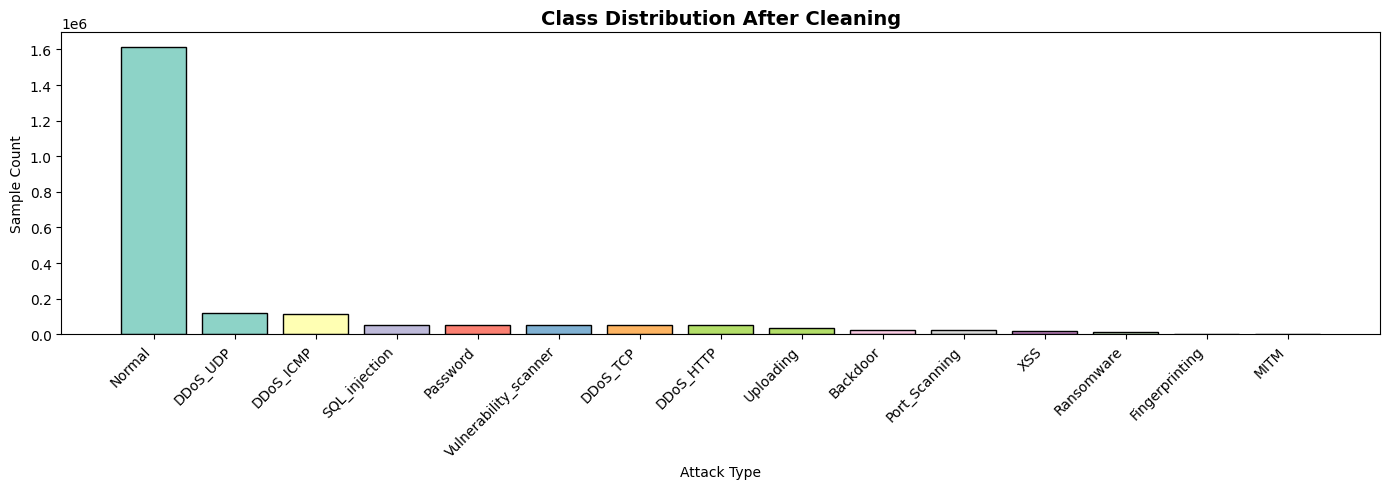


=== Class Distribution Summary ===
Attack_type
Normal                   1615643
DDoS_UDP                  121567
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
Fingerprinting              1001
MITM                         395
Name: count, dtype: int64

Imbalance Ratio (Max/Min): 4090.24x


In [25]:
# Visualize class imbalance
plt.figure(figsize=(14, 5))

# Before any balancing - just visualize
counts = df['Attack_type'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(counts)))

plt.bar(counts.index, counts.values, color=colors, edgecolor='black')
plt.title('Class Distribution After Cleaning', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n=== Class Distribution Summary ===")
print(counts)
print(f"\nImbalance Ratio (Max/Min): {counts.max() / counts.min():.2f}x")

# **Train/Test Split**

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y            # Maintain class distribution
)

print("=== Train/Test Split ===")
print(f"X_train Shape : {X_train.shape}")
print(f"X_test  Shape : {X_test.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"y_test  Shape : {y_test.shape}")

=== Train/Test Split ===
X_train Shape : (1774704, 53)
X_test  Shape : (443677, 53)
y_train Shape : (1774704,)
y_test  Shape : (443677,)


In [27]:
print("=" * 50)
print("   PREPROCESSING COMPLETE - SUMMARY")
print("=" * 50)
print(f"  Final Dataset Shape  : {df.shape}")
print(f"  Total Features       : {X_scaled.shape[1]}")
print(f"  Total Classes        : {y.nunique()}")
print(f"  Training Samples     : {X_train.shape[0]}")
print(f"  Testing Samples      : {X_test.shape[0]}")
print(f"  Missing Values       : {df.isnull().sum().sum()}")
print(f"  Infinite Values      : {np.isinf(df[numeric_cols]).sum().sum()}")
print("=" * 50)
print("  Ready for Step 3: Feature Engineering!")
print("=" * 50)

   PREPROCESSING COMPLETE - SUMMARY
  Final Dataset Shape  : (2218381, 55)
  Total Features       : 53
  Total Classes        : 15
  Training Samples     : 1774704
  Testing Samples      : 443677
  Missing Values       : 0
  Infinite Values      : 0
  Ready for Step 3: Feature Engineering!


# **Feature Engineering & Imbalance Handling**

In [31]:

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# **Feature Selection (Method 1: Correlation Filter)**

In [33]:
# Remove highly correlated features (threshold > 0.95)
print("=== Removing Highly Correlated Features ===")

corr_matrix = X_train.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns to drop
high_corr_cols = [col for col in upper_triangle.columns
                  if any(upper_triangle[col] > 0.95)]

print(f"Highly correlated features to drop: {len(high_corr_cols)}")
print(high_corr_cols)

# Drop from both train and test
X_train = X_train.drop(columns=high_corr_cols, errors='ignore')
X_test  = X_test.drop(columns=high_corr_cols, errors='ignore')

print(f"\nShape after correlation filter: {X_train.shape}")

=== Removing Highly Correlated Features ===
Highly correlated features to drop: 6
['mqtt.conflags', 'mqtt.msgtype', 'mqtt.proto_len', 'mqtt.topic_len', 'mqtt.ver', 'Attack_label']

Shape after correlation filter: (1774704, 47)


**Feature Selection (Method 2: SelectKBest)**

In [34]:
print("=== Selecting Top K Best Features ===")

# Use mutual info for multiclass classification
selector = SelectKBest(score_func=mutual_info_classif, k=40)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected  = selector.transform(X_test)

# Get selected feature names
selected_mask   = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()

print(f"Selected {len(selected_features)} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")

=== Selecting Top K Best Features ===
Selected 40 features:
   1. frame.time
   2. arp.opcode
   3. arp.hw.size
   4. icmp.checksum
   5. icmp.seq_le
   6. http.file_data
   7. http.content_length
   8. http.request.uri.query
   9. http.request.method
  10. http.referer
  11. http.request.full_uri
  12. http.request.version
  13. http.response
  14. tcp.ack
  15. tcp.ack_raw
  16. tcp.checksum
  17. tcp.connection.fin
  18. tcp.connection.rst
  19. tcp.connection.syn
  20. tcp.connection.synack
  21. tcp.dstport
  22. tcp.flags
  23. tcp.flags.ack
  24. tcp.len
  25. tcp.options
  26. tcp.payload
  27. tcp.seq
  28. tcp.srcport
  29. udp.port
  30. udp.stream
  31. udp.time_delta
  32. dns.qry.name
  33. dns.qry.name.len
  34. mqtt.conack.flags
  35. mqtt.conflag.cleansess
  36. mqtt.hdrflags
  37. mqtt.len
  38. mqtt.msg
  39. mqtt.protoname
  40. mqtt.topic


In [35]:
# Convert back to DataFrame
X_train_selected = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_selected  = pd.DataFrame(X_test_selected,  columns=selected_features)

print(f"\nX_train after selection: {X_train_selected.shape}")
print(f"X_test  after selection: {X_test_selected.shape}")


X_train after selection: (1774704, 40)
X_test  after selection: (443677, 40)


# **Feature Importance (Random Forest Validation)**

=== Validating Features with Random Forest Importance ===


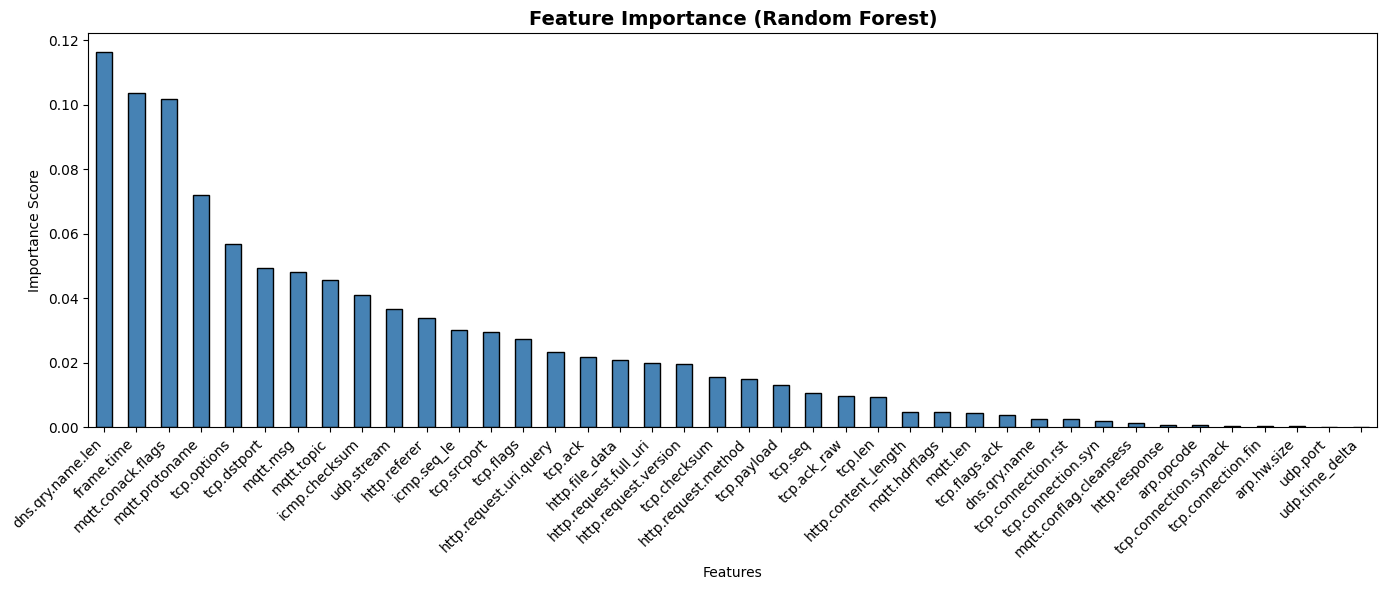


Top 10 Most Important Features:
dns.qry.name.len     0.116342
frame.time           0.103592
mqtt.conack.flags    0.101652
mqtt.protoname       0.072127
tcp.options          0.056712
tcp.dstport          0.049382
mqtt.msg             0.048037
mqtt.topic           0.045693
icmp.checksum        0.041071
udp.stream           0.036601
dtype: float64


In [36]:
print("=== Validating Features with Random Forest Importance ===")

# Quick RF on sample to get feature importance
rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Use small sample for speed
sample_size = min(50000, len(X_train_selected))
idx = np.random.choice(len(X_train_selected), sample_size, replace=False)

rf.fit(X_train_selected.iloc[idx], y_train.iloc[idx])

# Plot feature importance
importances = pd.Series(
    rf.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(importances.head(10))

In [28]:
!git config --global user.email "shamiulislam693@gmail.com"
!git config --global user.name "Shamiul-693"

In [29]:
import os
from google.colab import userdata

# 1. Your Specific Details
GIT_USERNAME = "Shamiul-693"
GIT_EMAIL = "shamiulislam693@gmail.com"
REPO_NAME = "CICadversarial"

# 2. Securely get your token from Colab Secrets
# IMPORTANT: Replace 'GITHUB_TOKEN_NAME' with the actual name you set for your secret in Colab's 'Secrets' tab.
# For example, if you named your secret 'MY_GITHUB_TOKEN', then use userdata.get('MY_GITHUB_TOKEN').
GIT_TOKEN = userdata.get('GITHUB_TOKEN_NAME')
remote_url = f"https://{GIT_TOKEN}@github.com/{GIT_USERNAME}/{REPO_NAME}.git"

# 3. Directory Management (Prevents nested folders)
os.chdir('/content')
if not os.path.exists(REPO_NAME):
    print(f"Cloning {REPO_NAME}...")
    !git clone {remote_url}
os.chdir(REPO_NAME)

# 4. Git Identity Configuration
!git config --global user.email "{GIT_EMAIL}"
!git config --global user.name "{GIT_USERNAME}"

# 5. Copy the Notebook (Wildcard handles the long filename)
# This copies your current work into the local repo folder
!cp /content/*.ipynb .

# 6. Push to GitHub
!git add .
!git commit -m "Update from Google Colab - {pd.Timestamp.now()}"
!git push {remote_url} main

Cloning CICadversarial...
Cloning into 'CICadversarial'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 21 (delta 2), reused 7 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 836.27 KiB | 3.34 MiB/s, done.
Resolving deltas: 100% (2/2), done.
cp: cannot stat '/content/*.ipynb': No such file or directory
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [30]:
import os

# 1. Find where the notebook actually is
# This command searches the entire Colab environment for your .ipynb file
notebook_path = !find /content -name "*.ipynb" | grep -v ".ipynb_checkpoints"
if notebook_path:
    actual_file = notebook_path[0]
    print(f"Found notebook at: {actual_file}")

    # 2. Go to your repo folder
    REPO_NAME = "CICadversarial"
    %cd /content/{REPO_NAME}

    # 3. Copy it here specifically
    !cp "{actual_file}" .
    print("File copied successfully. Ready to push.")
else:
    print("Could not find any .ipynb files. Did you rename it?")

# 4. Standard Push
!git add .
!git commit -m "Fixed path and updated notebook"
!git push origin main

Found notebook at: /content/drive/MyDrive/brain stroke/Brain Stroke Prediction  (1).ipynb
/content
File copied successfully. Ready to push.
[main c481c8f] Fixed path and updated notebook
 1 file changed, 4789 insertions(+)
 create mode 100644 Brain Stroke Prediction  (1).ipynb
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 830.00 KiB | 138.33 MiB/s, done.
Total 3 (delta 0), reused 2 (delta 0), pack-reused 0
To https://github.com/Shamiul-693/CICadversarial.git
   1d55f63..c481c8f  main -> main
